In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('ShopSphere_Dataset.csv',parse_dates = ['InvoiceDate'])
data

,InvoiceNo,InvoiceDate,CustomerID,StockCode,Description,Quantity,UnitPrice,Country
0,400000,2024-01-21 03:01:47,10000,40565,Groceries,31,5.56,United Kingdom
1,400000,2024-01-21 03:01:47,10000,40048,Fashion,14,34.86,United Kingdom
2,400000,2024-01-21 03:01:47,10000,40149,Electronics,48,149.66,United States
3,400000,2024-01-21 03:01:47,10000,40514,Sports & Outdoors,7,38.30,United States
4,400000,2024-01-21 03:01:47,10000,40607,Groceries,4,7.66,United States
...,...,...,...,...,...,...,...,...
385309,420989,2024-10-11 09:01:10,14371,40623,Groceries,35,20.17,United States
385310,420989,2024-10-11 09:01:10,14371,40504,Sports & Outdoors,54,37.31,United States
385311,420989,2024-10-11 09:01:10,14371,40189,Home & Living,83,18.24,United States
385312,420989,2024-10-11 09:01:10,14371,40299,Beauty & Wellness,100,39.94,United States


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 385314 entries, 0 to 385313
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    385314 non-null  int64         
 1   InvoiceDate  385314 non-null  datetime64[ns]
 2   CustomerID   385314 non-null  int64         
 3   StockCode    385314 non-null  int64         
 4   Description  385314 non-null  object        
 5   Quantity     385314 non-null  int64         
 6   UnitPrice    385314 non-null  float64       
 7   Country      385314 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(2)
memory usage: 23.5+ MB


In [4]:
data.describe(include = 'all')

,InvoiceNo,InvoiceDate,CustomerID,StockCode,Description,Quantity,UnitPrice,Country
count,385314.000000,385314,385314.000000,385314.000000,385314,385314.000000,385314.000000,385314
unique,NaN,NaN,NaN,NaN,10,NaN,NaN,2
top,NaN,NaN,NaN,NaN,Fashion,NaN,NaN,United States
freq,NaN,NaN,NaN,NaN,69110,NaN,NaN,308618
mean,410481.180074,2024-08-02 00:30:08.128438528,12178.170819,40339.113494,NaN,50.503283,46.416868,NaN
min,400000.000000,2023-12-01 00:25:31,10000.000000,40000.000000,NaN,1.000000,1.000000,NaN
25%,405223.000000,2024-05-14 14:00:08,11078.000000,40127.000000,NaN,31.000000,16.370000,NaN
50%,410453.000000,2024-08-20 04:54:48,12151.000000,40288.000000,NaN,51.000000,33.590000,NaN
75%,415747.000000,2024-11-02 13:06:42,13285.000000,40559.000000,NaN,70.000000,62.310000,NaN
max,420989.000000,2024-12-31 23:52:56,14371.000000,40799.000000,NaN,100.000000,384.900000,NaN


#### Data Cleaning

In [5]:
data.isnull().sum()

InvoiceNo      0
InvoiceDate    0
CustomerID     0
StockCode      0
Description    0
Quantity       0
UnitPrice      0
Country        0
dtype: int64

In [6]:
data = data.dropna(subset = ['CustomerID'])

In [7]:
data['CustomerID'] = data['CustomerID'].astype(int).astype(str)
data['Revenue'] = data['Quantity'] * data['UnitPrice']

In [8]:
data.head()

,InvoiceNo,InvoiceDate,CustomerID,StockCode,Description,Quantity,UnitPrice,Country,Revenue
0,400000,2024-01-21 03:01:47,10000,40565,Groceries,31,5.56,United Kingdom,172.36
1,400000,2024-01-21 03:01:47,10000,40048,Fashion,14,34.86,United Kingdom,488.04
2,400000,2024-01-21 03:01:47,10000,40149,Electronics,48,149.66,United States,7183.68
3,400000,2024-01-21 03:01:47,10000,40514,Sports & Outdoors,7,38.30,United States,268.10
4,400000,2024-01-21 03:01:47,10000,40607,Groceries,4,7.66,United States,30.64


##### Observing Unique Values in Categorical Features for inconsistency 

In [9]:
for column in data:
    if column not in ['InvoiceNo','InvoiceDate','CustomerID','StockCode','Quantity','UnitPrice','Revenue']:
         print(data[column].value_counts())
        
   

Description
Fashion              69110
Home & Living        53811
Electronics          46211
Groceries            42163
Beauty & Wellness    38595
Sports & Outdoors    30966
Automotive           30963
Toys                 27220
Stationery           23148
Books                23127
Name: count, dtype: int64
Country
United States     308618
United Kingdom     76696
Name: count, dtype: int64


In [10]:
print('Rows with non positive Quantity', (data['Quantity'] <= 0).sum())
print('Rows with non positive UnitPrice', (data['UnitPrice'] <= 0).sum())

Rows with non positive Quantity 0
Rows with non positive UnitPrice 0


#### Exploratory Data Analysis

In [11]:
num_Customer  = data['CustomerID'].nunique()
num_Transaction = data['InvoiceNo'].nunique()
num_Product = data['StockCode'].nunique() 
Date_Range = data['InvoiceDate'].min(), data['InvoiceDate'].max()

In [12]:
print(f'Number of Customer: {num_Customer}')
print(f'Number of Transaction: {num_Transaction}')
print(f'Number of Product: {num_Product}')
print(f'Data_Range {Date_Range[0]} to {Date_Range[1]}')


Number of Customer: 4372
Number of Transaction: 20990
Number of Product: 800
Data_Range 2023-12-01 00:25:31 to 2024-12-31 23:52:56


In [13]:
data.head(2)

,InvoiceNo,InvoiceDate,CustomerID,StockCode,Description,Quantity,UnitPrice,Country,Revenue
0,400000,2024-01-21 03:01:47,10000,40565,Groceries,31,5.56,United Kingdom,172.36
1,400000,2024-01-21 03:01:47,10000,40048,Fashion,14,34.86,United Kingdom,488.04


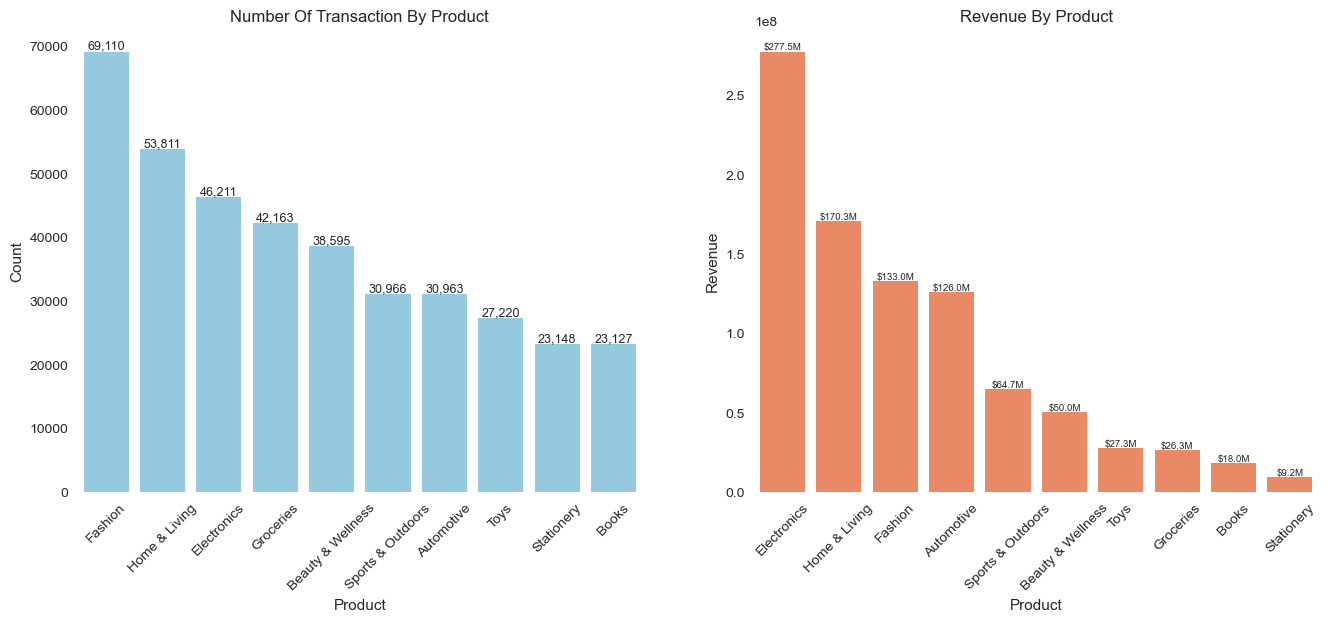

In [85]:
# count of transaction by Product and Revenue Generated by products
fig , ax = plt.subplots(nrows = 1, ncols = 2, figsize = (16,6))
ax= ax.flatten()

sns.countplot(x = data['Description'],
              order = data['Description'].value_counts().index,
              ax = ax[0],
              color = 'skyblue'
             )
ax[0].set_xlabel('Product')
ax[0].set_ylabel('Count')
ax[0].set_title('Number Of Transaction By Product')
ax[0].tick_params(rotation = 45, axis = 'x')
ax[0].grid(False)
ax[0].spines[:].set_visible(False)
for c in ax[0].containers:
    ax[0].bar_label(c, fontsize = 9, labels = [f'{int(v):,}' for v in c.datavalues])


prod_revenue = data.groupby('Description')['Revenue'].sum().reset_index().sort_values('Revenue',ascending = False)

sns.barplot(x = prod_revenue['Description'], 
            y =prod_revenue['Revenue'],
            ax = ax[1],color = 'coral',
           )
ax[1].tick_params(axis = 'x', rotation = 45)
ax[1].set_xlabel('Product')
ax[1].set_ylabel('Revenue')
ax[1].set_title('Revenue By Product')
ax[1].grid(False)
ax[1].spines[:].set_visible(False)
for c in ax[1].containers:
    ax[1].bar_label(c, fontsize =7, labels = [f'${v/1000000:.1f}M' for v in c.datavalues])
  


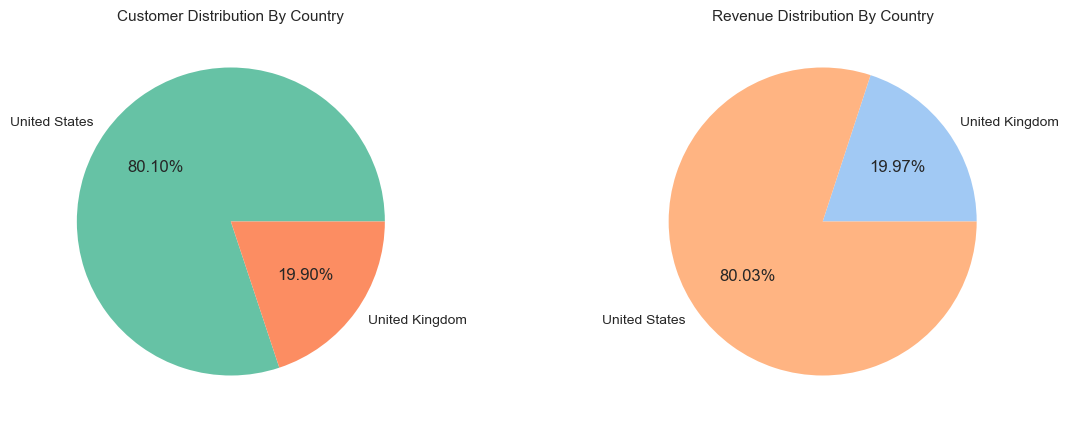

In [75]:
#country generate the highest revenue and with the highest customer
revenue_country = data.groupby('Country')['Revenue'].sum()
fig, ax = plt.subplots(figsize = (14,5), nrows = 1, ncols = 2)
ax = ax.flatten()
count = data['Country'].value_counts()
colors = sns.color_palette("Set2")
colors_1 = sns.color_palette("pastel")
ax[0].pie(x = count.values, labels = count.index, autopct = '%.2f%%',colors = colors)
ax[0].set_title('Customer Distribution By Country',fontsize = 11)

ax[1].pie(x = revenue_country.values, labels = revenue_country.index, autopct = '%.2f%%', colors = colors_1)
ax[1].set_title('Revenue Distribution By Country', fontsize = 11)
plt.show()

The United States dominates both customer count and revenue, indicating that revenue is mainly driven by the large number of customers rather than higher spending per customer. The United Kingdom represents a smaller market with lower customer activity.`

#### Time Series Analysis

In [16]:
data['InvoiceMonths'] = data['InvoiceDate'].dt.to_period('M')

In [17]:
monthly_Revenue = data.groupby('InvoiceMonths')['Revenue'].sum().reset_index()

In [18]:
monthly_Revenue['InvoiceMonths'] = monthly_Revenue['InvoiceMonths'].astype(str)

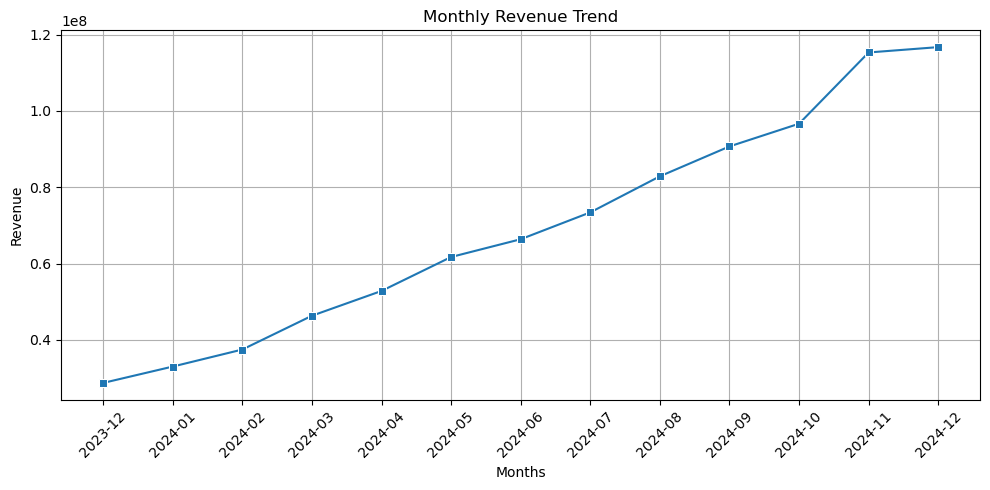

In [19]:
plt.figure(figsize = (10,5))
sns.lineplot(x = 'InvoiceMonths', y = 'Revenue', data = monthly_Revenue,marker = 's' )
plt.xticks(rotation = 45)
plt.xlabel('Months')
plt.ylabel('Revenue')
plt.title('Monthly Revenue Trend')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Cohort Analysis

Why Cohort Analysis?

Cohort Analysis is grouping customers who share something in common (like the month they made their first purchase) and tracking them over time.
Instead of looking at the customer base at once, we look at each group's retention separately.

This way, we can:

See exactly when customers start dropping off.

Compare groups to see if certain strategies work better.

Build targeted retention strategies.

In [20]:
cohort_data = data.groupby('CustomerID')['InvoiceMonths'].min()
cohort_data.name = 'CohortMonth'


In [21]:
data = data.merge(cohort_data,on = 'CustomerID')

In [22]:
data.head()

,InvoiceNo,InvoiceDate,CustomerID,StockCode,Description,Quantity,UnitPrice,Country,Revenue,InvoiceMonths,CohortMonth
0,400000,2024-01-21 03:01:47,10000,40565,Groceries,31,5.56,United Kingdom,172.36,2024-01,2024-01
1,400000,2024-01-21 03:01:47,10000,40048,Fashion,14,34.86,United Kingdom,488.04,2024-01,2024-01
2,400000,2024-01-21 03:01:47,10000,40149,Electronics,48,149.66,United States,7183.68,2024-01,2024-01
3,400000,2024-01-21 03:01:47,10000,40514,Sports & Outdoors,7,38.30,United States,268.10,2024-01,2024-01
4,400000,2024-01-21 03:01:47,10000,40607,Groceries,4,7.66,United States,30.64,2024-01,2024-01


In [23]:
invoice_year,invoice_months = data['InvoiceMonths'].dt.year, data['InvoiceMonths'].dt.month
cohort_year,cohort_months  = data['CohortMonth'].dt.year, data['CohortMonth'].dt.month

In [24]:
year_diff = invoice_year - cohort_year 
months_diff = invoice_months -  cohort_months


In [25]:
data['CohortIndex'] = year_diff *12 + months_diff + 1

In [26]:
data.tail(20)

,InvoiceNo,InvoiceDate,CustomerID,StockCode,Description,Quantity,UnitPrice,Country,Revenue,InvoiceMonths,CohortMonth,CohortIndex
385294,420988,2024-09-13 20:45:34,14371,40040,Fashion,25,45.26,United Kingdom,1131.50,2024-09,2024-05,5
385295,420989,2024-10-11 09:01:10,14371,40178,Home & Living,52,51.52,United States,2679.04,2024-10,2024-05,6
385296,420989,2024-10-11 09:01:10,14371,40480,Sports & Outdoors,66,33.39,United States,2203.74,2024-10,2024-05,6
385297,420989,2024-10-11 09:01:10,14371,40047,Fashion,91,57.54,United States,5236.14,2024-10,2024-05,6
385298,420989,2024-10-11 09:01:10,14371,40420,Toys,17,30.03,United Kingdom,510.51,2024-10,2024-05,6
385299,420989,2024-10-11 09:01:10,14371,40402,Toys,59,16.70,United States,985.30,2024-10,2024-05,6
385300,420989,2024-10-11 09:01:10,14371,40294,Beauty & Wellness,69,30.04,United States,2072.76,2024-10,2024-05,6
385301,420989,2024-10-11 09:01:10,14371,40090,Electronics,100,138.66,United States,13866.00,2024-10,2024-05,6
385302,420989,2024-10-11 09:01:10,14371,40209,Home & Living,50,200.50,United States,10025.00,2024-10,2024-05,6
385303,420989,2024-10-11 09:01:10,14371,40311,Beauty & Wellness,54,21.03,United Kingdom,1135.62,2024-10,2024-05,6


In [27]:
cohort_count = data.groupby(['CohortMonth','CohortIndex'])['CustomerID'].nunique().reset_index()

In [28]:
cohort_pivot = cohort_count.pivot(index = 'CohortMonth', columns = 'CohortIndex', values = 'CustomerID')
cohort_pivot

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2023-12,344.0,79.0,73.0,97.0,90.0,90.0,95.0,100.0,96.0,118.0,94.0,138.0,83.0
2024-01,329.0,78.0,94.0,93.0,76.0,92.0,88.0,84.0,90.0,101.0,87.0,131.0,NaN
2024-02,337.0,86.0,95.0,94.0,83.0,96.0,82.0,99.0,94.0,109.0,106.0,NaN,NaN
2024-03,334.0,73.0,86.0,99.0,91.0,98.0,88.0,95.0,106.0,98.0,NaN,NaN,NaN
2024-04,334.0,101.0,86.0,92.0,96.0,103.0,93.0,92.0,91.0,NaN,NaN,NaN,NaN
2024-05,349.0,91.0,81.0,94.0,103.0,102.0,109.0,90.0,NaN,NaN,NaN,NaN,NaN
2024-06,312.0,76.0,74.0,80.0,82.0,98.0,86.0,NaN,NaN,NaN,NaN,NaN,NaN
2024-07,347.0,107.0,82.0,89.0,98.0,103.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-08,335.0,81.0,80.0,92.0,93.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
cohort_size = cohort_pivot.iloc[:,0] 
retention = cohort_pivot.divide(cohort_size ,axis = 0).round(3)
retention 

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2023-12,1.0,0.230,0.212,0.282,0.262,0.262,0.276,0.291,0.279,0.343,0.273,0.401,0.241
2024-01,1.0,0.237,0.286,0.283,0.231,0.280,0.267,0.255,0.274,0.307,0.264,0.398,NaN
2024-02,1.0,0.255,0.282,0.279,0.246,0.285,0.243,0.294,0.279,0.323,0.315,NaN,NaN
2024-03,1.0,0.219,0.257,0.296,0.272,0.293,0.263,0.284,0.317,0.293,NaN,NaN,NaN
2024-04,1.0,0.302,0.257,0.275,0.287,0.308,0.278,0.275,0.272,NaN,NaN,NaN,NaN
2024-05,1.0,0.261,0.232,0.269,0.295,0.292,0.312,0.258,NaN,NaN,NaN,NaN,NaN
2024-06,1.0,0.244,0.237,0.256,0.263,0.314,0.276,NaN,NaN,NaN,NaN,NaN,NaN
2024-07,1.0,0.308,0.236,0.256,0.282,0.297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-08,1.0,0.242,0.239,0.275,0.278,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


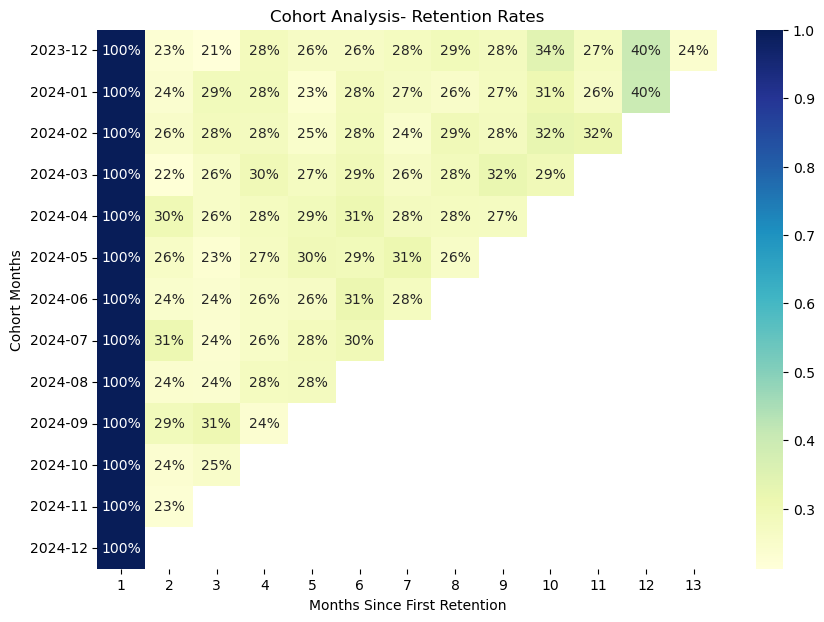

In [30]:
plt.figure(figsize = (10,7))
sns.heatmap(retention,annot = True,fmt = '.0%',cmap = 'YlGnBu')
plt.title('Cohort Analysis- Retention Rates')
plt.xlabel('Months Since First Retention')
plt.ylabel('Cohort Months')
plt.show()

#### RFM Analysis

In [31]:
reference_date = data['InvoiceDate'].max() + pd.Timedelta(days=1)
print('Refence date for recency:',reference_date)
rfm = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': pd.Series.nunique,
    'Revenue': 'sum'
}).reset_index()
rfm.columns = 'CustomerID','Recency_days','Frequency','Monetary'
display(rfm.describe().T)
display(rfm.head())

Refence date for recency: 2025-01-01 23:52:56


,count,mean,std,min,25%,50%,75%,max
Recency_days,4372.0,68.533166,66.232469,1.00,18.00,47.000,98.000,384.00
Frequency,4372.0,4.801006,3.307503,1.00,2.00,4.000,7.000,26.00
Monetary,4372.0,206387.424604,146325.615580,9174.83,92576.33,175626.845,287072.105,1235162.66


,CustomerID,Recency_days,Frequency,Monetary
0,10000,140,5,242993.87
1,10001,86,1,20841.75
2,10002,23,6,254693.19
3,10003,89,2,115314.08
4,10004,100,7,305794.35


In [32]:
from sklearn.preprocessing import StandardScaler
x = rfm[['CustomerID','Recency_days','Frequency','Monetary']].copy()
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)


In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
sil_score = []
k_range = range(2,11)
for k in k_range:
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    labels = km.fit_predict(x_scaled)
    inertia.append(km.inertia_)
    sil_score.append(silhouette_score(x_scaled,labels))

Text(0, 0.5, 'Inertia')

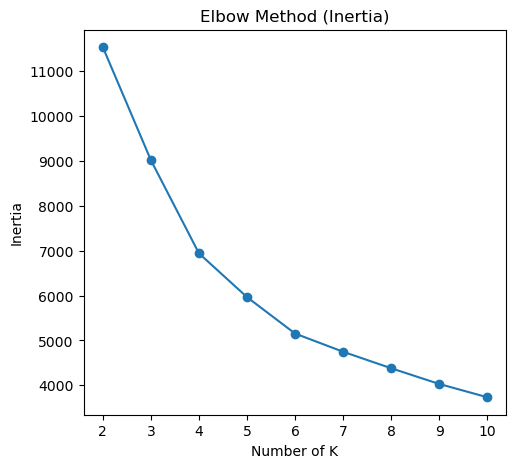

In [34]:
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
plt.plot(k_range, inertia , marker = 'o')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of K')
plt.ylabel('Inertia')


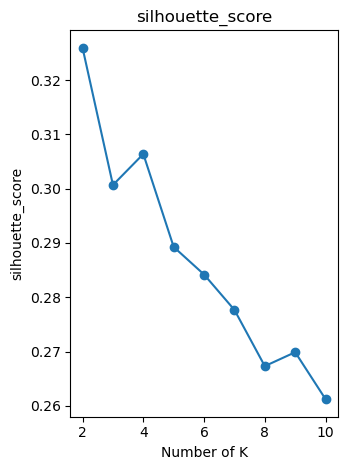

In [35]:
plt.subplot(1,2,2)
plt.plot(k_range,sil_score,marker = 'o')
plt.title('silhouette_score')
plt.xlabel('Number of K')
plt.ylabel('silhouette_score')
plt.tight_layout()
plt.show()


In [36]:
print('silhouette_score per k:', dict(zip(k_range,np.round(sil_score,3))))

silhouette_score per k: {2: np.float64(0.326), 3: np.float64(0.301), 4: np.float64(0.306), 5: np.float64(0.289), 6: np.float64(0.284), 7: np.float64(0.278), 8: np.float64(0.267), 9: np.float64(0.27), 10: np.float64(0.261)}


KElbowVisualizer(ax=<Axes: >, estimator=KMeans(n_clusters=9, random_state=42),
                 k=(2, 10))

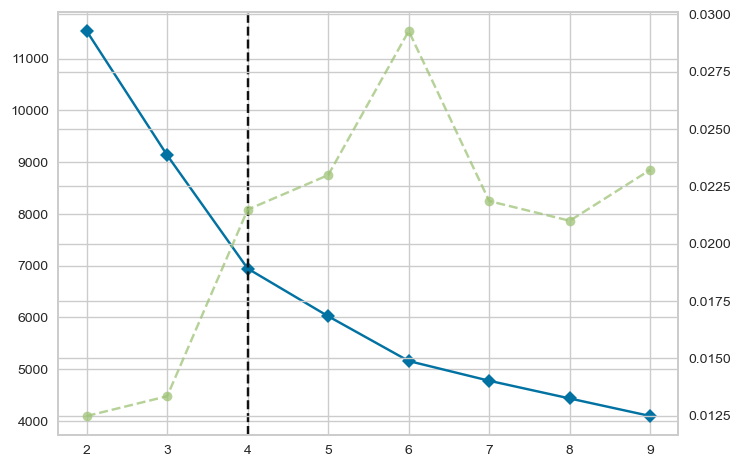

In [40]:
from yellowbrick.cluster import KElbowVisualizer
model = KMeans(random_state = 42)
visualizer = KElbowVisualizer(model,k = (2,10)) 
visualizer.fit(x_scaled)


In [42]:
final_k = 4
kmeans = KMeans(n_clusters = final_k , random_state = 42)
kmeans.fit(x_scaled)

KMeans(n_clusters=4, random_state=42)

In [44]:
rfm['clusters'] = kmeans.labels_

In [50]:
rfm.head()

,CustomerID,Recency_days,Frequency,Monetary,clusters
0,10000,140,5,242993.87,0
1,10001,86,1,20841.75,0
2,10002,23,6,254693.19,0
3,10003,89,2,115314.08,0
4,10004,100,7,305794.35,0


In [54]:
# group by cluster
cluster_profile = rfm.groupby('clusters').agg({
    'Recency_days': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns = {'CustomerID': 'Num_clusters'} ).round(1)
cluster_profile 

,Recency_days,Frequency,Monetary,Num_clusters
clusters,,,,
0,47.4,3.5,146918.3,1341
1,48.6,3.6,152522.6,1435
2,192.9,3.0,129319.8,653
3,42.8,9.8,426291.2,943


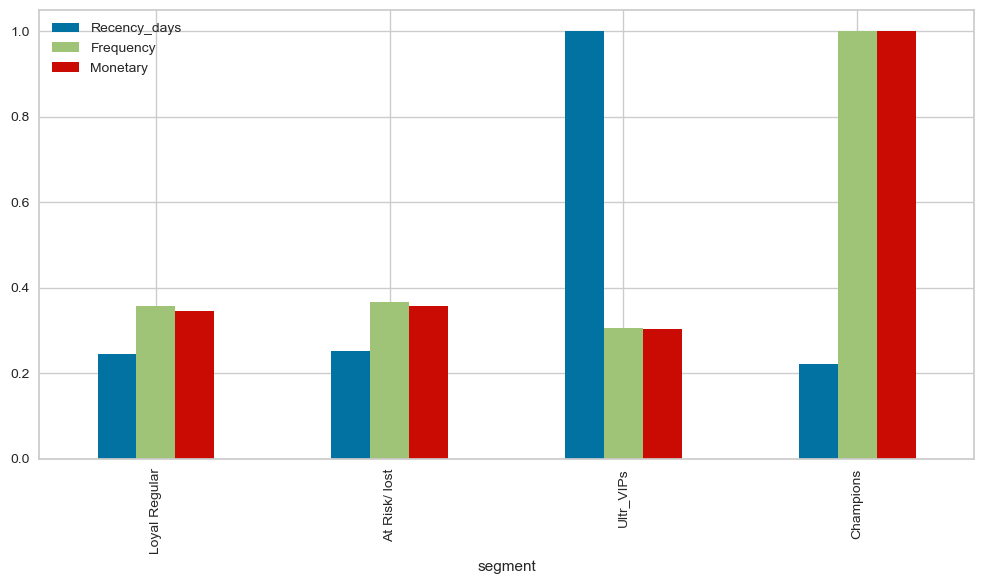

In [64]:
cluster_name = {
    0: 'Loyal Regular',
    1: 'At Risk/ lost',
    2: 'Ultr_VIPs',
    3: 'Champions'
}
cluster_profile['segment'] = cluster_profile.index.map(cluster_name)
df_plot = cluster_profile.copy()
df_plot[['Recency_days', 'Frequency', 'Monetary']] = df_plot[
    ['Recency_days', 'Frequency', 'Monetary']
].apply(lambda x:x/x.max())

df_plot.set_index('segment')[['Recency_days', 'Frequency', 'Monetary']].plot(kind = 'bar',figsize = (10,6))
plt.tight_layout()
plt.show()
